<a href="https://colab.research.google.com/github/MuzammilBughio/Machine-Learning-Practice-and-Projects-/blob/main/DecisionTreeClassifierPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [38]:
titanic = sns.load_dataset('titanic')

In [40]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [41]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [42]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [43]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [44]:
# Feature Selection

features = ['pclass' , 'age' , 'sex' , 'embarked' ,'fare']
target = ['survived']

In [45]:
# missing values
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy='median')
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy='most_frequent')
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [46]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [47]:
# Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [48]:
# Split data

X = titanic[features]
y= titanic [target]

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state =42 )


In [49]:
# Model - Decision Tree (without puring)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , recall_score , precision_score , f1_score
model = DecisionTreeClassifier()

model.fit(X_train , y_train)
y_pred = model.predict(X_test)

print("Confusion Matrix \n" , confusion_matrix(y_test , y_pred))
print("accuracy" , accuracy_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("Precision" , precision_score(y_test , y_pred))
print("F1 score" , f1_score(y_test , y_pred))


Confusion Matrix 
 [[129  28]
 [ 33  78]]
accuracy 0.7723880597014925
Recall 0.7027027027027027
Precision 0.7358490566037735
F1 score 0.7188940092165899


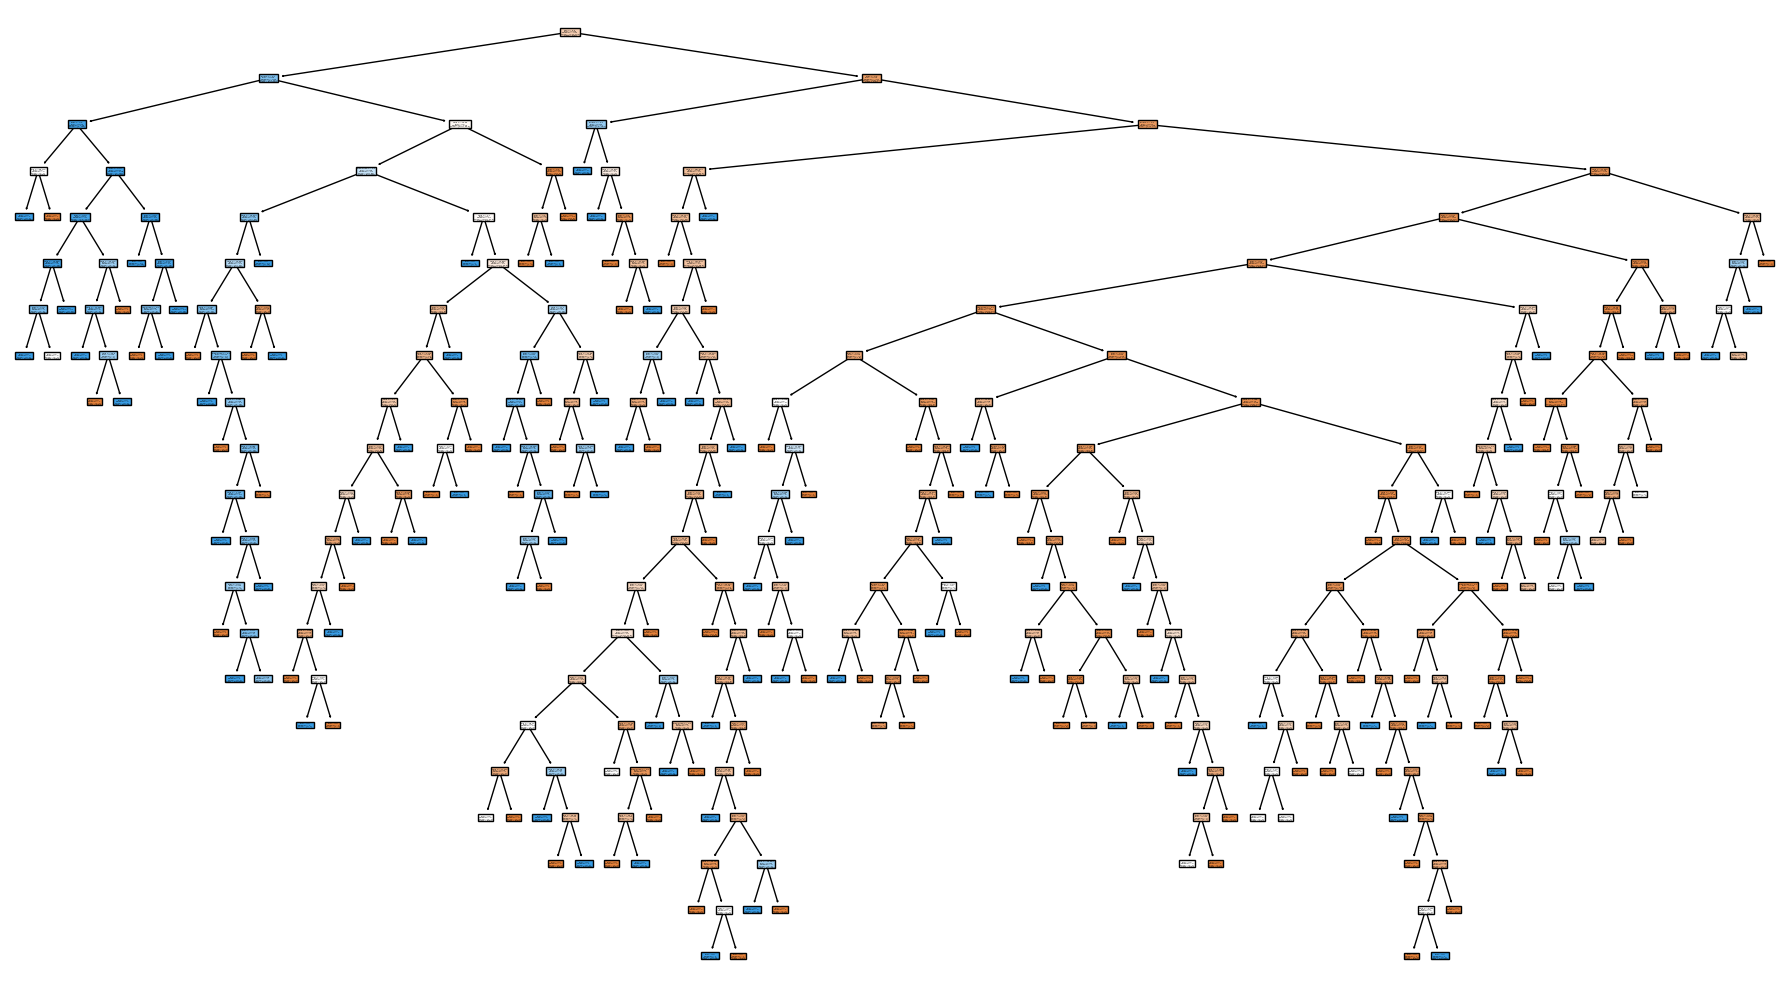

In [36]:
# plot tree
from sklearn.tree import plot_tree

plt.figure(figsize = (18 ,10))
plot_tree(
    model ,
    feature_names= X.columns,
    class_names = ['Died' , "Survived"],
    filled = True
)
plt.tight_layout()
plt.show()

In [77]:
# Model - Decision Tree (with puring but testing  pre puring parameters )
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , recall_score , precision_score , f1_score

# def nums ():
#   numlist =[]
#   for i in range(0, 105, 5):
#     val = i / 100
#     numlist.append(val)
#     return numlist

less_purity = [i for i in range(2,50)]

# max_depth = 4 , min_samples_split = 2 , min_samples_leaf =5 , min_impurity_decrease=0.0
max_acc =0
accuracy =0
for depth in less_purity:
  model = DecisionTreeClassifier(max_depth = 4 , min_samples_split=10, )
  model.fit(X_train , y_train)
  acc = model.score(X_test , y_test)
  print(f"min_samples_split {depth} is {acc}")
  if accuracy < acc:
    accuracy = acc
    max_acc = depth

print(f"\nBest accuracy is for min_samples_split {max_acc} is {accuracy}")



min_samples_split 2 is 0.8246268656716418
min_samples_split 3 is 0.8246268656716418
min_samples_split 4 is 0.8246268656716418
min_samples_split 5 is 0.8246268656716418
min_samples_split 6 is 0.8246268656716418
min_samples_split 7 is 0.8246268656716418
min_samples_split 8 is 0.8246268656716418
min_samples_split 9 is 0.8246268656716418
min_samples_split 10 is 0.8246268656716418
min_samples_split 11 is 0.8246268656716418
min_samples_split 12 is 0.8246268656716418
min_samples_split 13 is 0.8246268656716418
min_samples_split 14 is 0.8246268656716418
min_samples_split 15 is 0.8246268656716418
min_samples_split 16 is 0.8246268656716418
min_samples_split 17 is 0.8246268656716418
min_samples_split 18 is 0.8246268656716418
min_samples_split 19 is 0.8246268656716418
min_samples_split 20 is 0.8246268656716418
min_samples_split 21 is 0.8246268656716418
min_samples_split 22 is 0.8246268656716418
min_samples_split 23 is 0.8246268656716418
min_samples_split 24 is 0.8246268656716418
min_samples_split 2

In [80]:
# Model - Decision Tree (with  pre puring)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , recall_score , precision_score , f1_score
model = DecisionTreeClassifier(max_depth = 4 , min_samples_split = 2 , min_samples_leaf =5 , min_impurity_decrease=0.0 , random_state =42)

model.fit(X_train , y_train)
y_pred = model.predict(X_test)

print("Confusion Matrix \n" , confusion_matrix(y_test , y_pred))
print("accuracy" , accuracy_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("Precision" , precision_score(y_test , y_pred))
print("F1 score" , f1_score(y_test , y_pred))


Confusion Matrix 
 [[145  12]
 [ 41  70]]
accuracy 0.8022388059701493
Recall 0.6306306306306306
Precision 0.8536585365853658
F1 score 0.7253886010362695


In [89]:
# Model - Decision Tree (with  post puring)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , recall_score , precision_score , f1_score

full_tree = DecisionTreeClassifier(random_state =42)
full_tree.fit(X_train , y_train)

path = full_tree.cost_complexity_pruning_path(X_train , y_train)
ccp_alphas = path.ccp_alphas

#train model for each alpha
max_alpha =0
accuracy =0
for alpha in ccp_alphas:
  model_prepruning = full_tree = DecisionTreeClassifier(ccp_alpha=alpha ,random_state =42)
  model_prepruning.fit(X_train , y_train)
  acc = model_prepruning.score(X_test , y_test)
  # print(f"min_samples_split {alpha} is {acc}")
  if accuracy < acc:
    accuracy = acc
    max_alpha = alpha

print(f"\nBest accuracy is for ccp alpha {max_alpha} is {accuracy}")




Best accuracy is for ccp alpha 0.0017121455323702516 is 0.8171641791044776


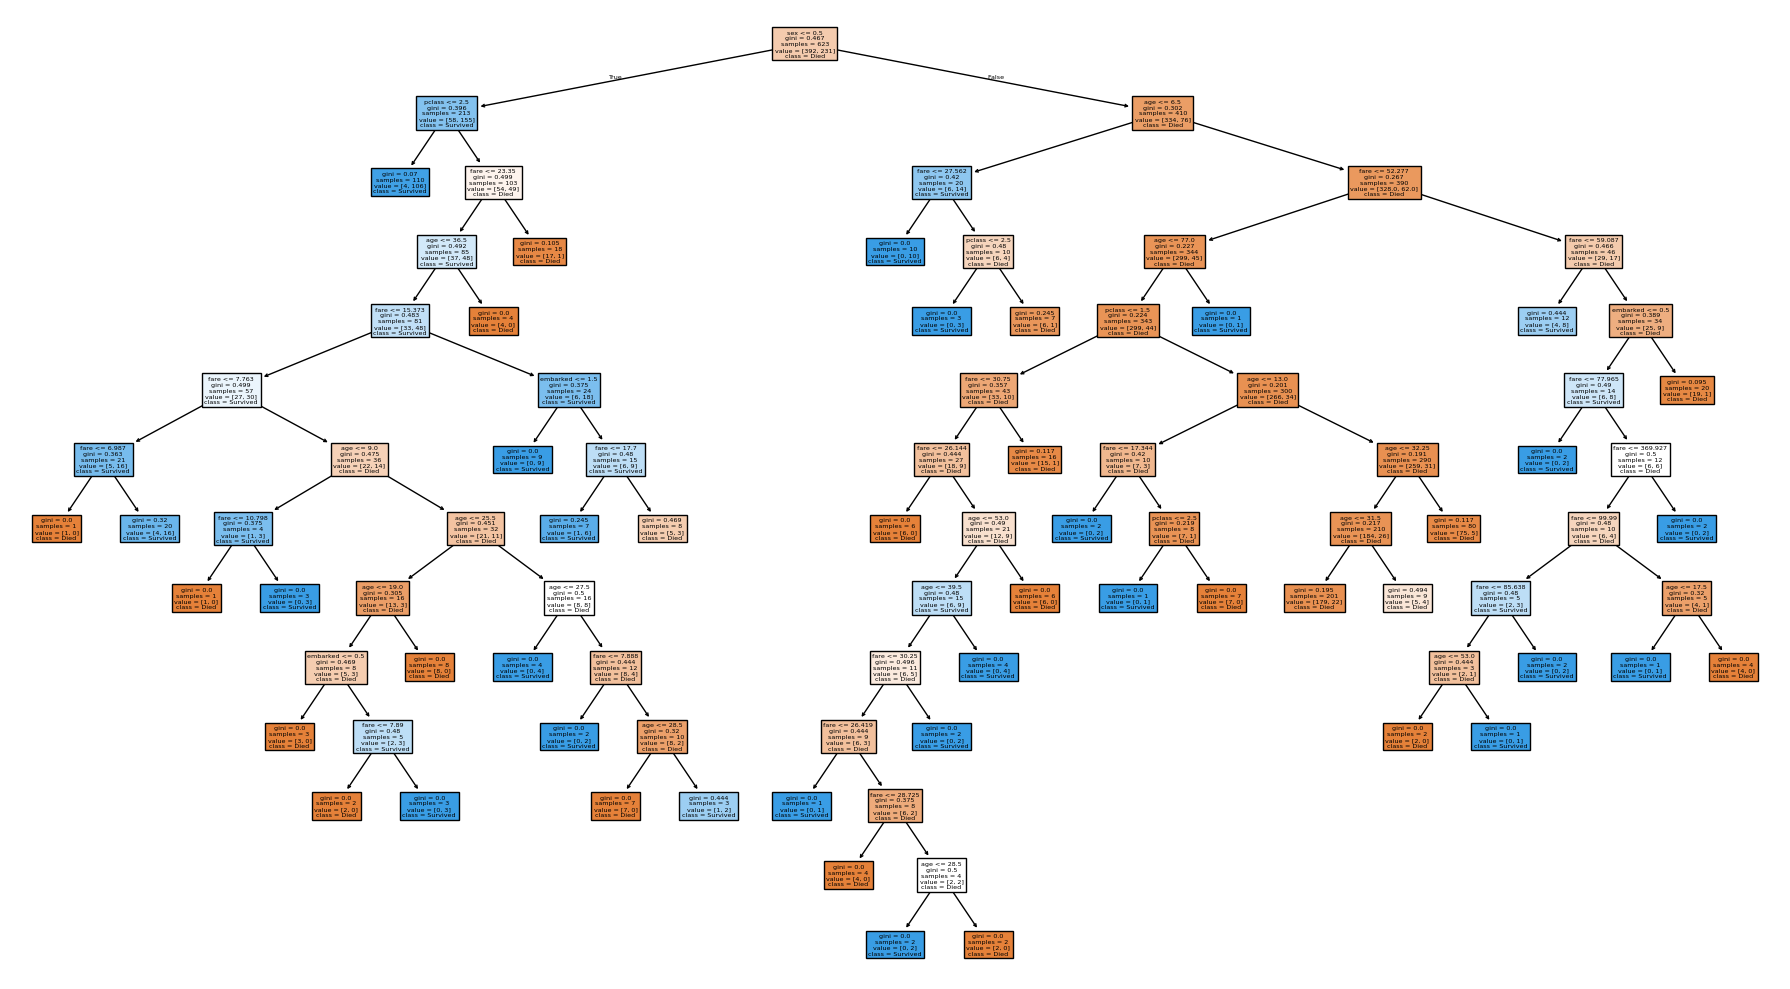

In [91]:
# best model with post pruning

best_model = DecisionTreeClassifier(ccp_alpha=max_alpha , random_state =42)
best_model.fit(X_train , y_train)

plt.figure(figsize = (18 ,10))
plot_tree(
    best_model ,
    feature_names= X.columns,
    class_names = ['Died' , "Survived"],
    filled = True
)
plt.tight_layout()
plt.show()


Best score:  0.8394863563402889



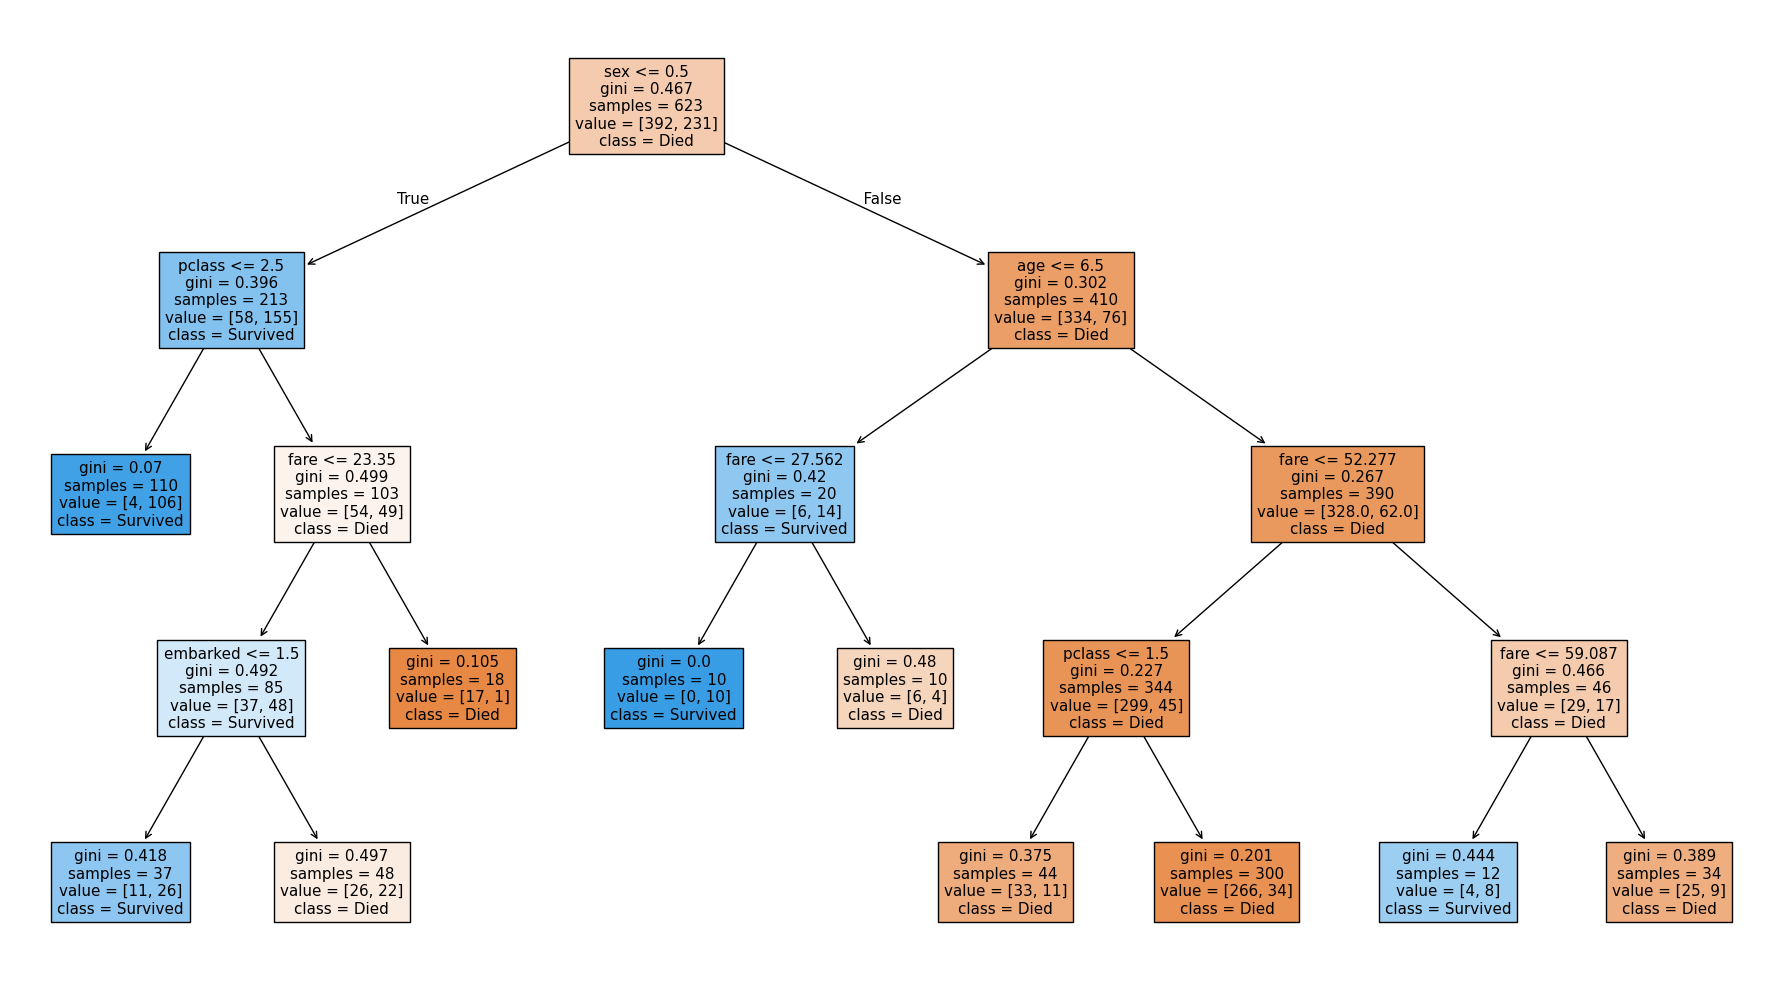

In [93]:
# Final Model with pre and post pruning
# best model with post pruning

final_model = DecisionTreeClassifier(max_depth = 4 , min_samples_split = 2 , min_samples_leaf =5 , min_impurity_decrease=0.0 ,ccp_alpha=max_alpha , random_state =42)
final_model.fit(X_train , y_train)

print("Best score: " ,final_model.score(X_train , y_train))
print()
plt.figure(figsize = (18 ,10))
plot_tree(
    best_model ,
    feature_names= X.columns,
    class_names = ['Died' , "Survived"],
    filled = True
)
plt.tight_layout()
plt.show()
